# Customer Churn Prediction & Causal Analysis of Retention TriggersEnd-to-end ML-проект для коммерческого мобильного сервиса.**Что внутри:**1. Сбор данных из PostgreSQL и парсинг сырых event-логов2. Feature engineering — 28 пользовательских признаков3. Обоснование таргета через survival-анализ4. Сравнение 5 моделей с time-based валидацией5. Обнаружение и устранение data leakage6. Тюнинг через Optuna (TimeSeriesSplit CV)7. Интерпретация через SHAP8. Каузальный анализ бонусных триггеров через Propensity Score Matching**Результат:**- AUC 0.92 на out-of-time валидации- Recall 97%, Precision 85% — для приоритизации retention-кампаний- Найден триггер с реальным положительным эффектом (+14.4% retention, p=0.027)- Найден триггер с обратным эффектом (-4.6%) — отключение высвобождает 17.5% бюджета

## 1. SetupВсе библиотеки и подключение к БД. Пароль читается из переменной окружения `DB_PASSWORD` — никаких credentials в коде.

In [ ]:
import osimport jsonimport warningsimport pandas as pdimport numpy as npfrom sqlalchemy import create_engine# ── Визуализация ─────────────────────────────────────────import matplotlib.pyplot as pltimport seaborn as sns# ── ML ───────────────────────────────────────────────────from sklearn.model_selection import TimeSeriesSplit, train_test_splitfrom sklearn.metrics import (roc_auc_score, classification_report,                             ConfusionMatrixDisplay, RocCurveDisplay,                             precision_score, recall_score, f1_score)from sklearn.linear_model import LogisticRegressionfrom sklearn.ensemble import RandomForestClassifierfrom sklearn.preprocessing import StandardScalerfrom sklearn.neighbors import NearestNeighborsfrom sklearn.pipeline import Pipelinefrom sklearn.compose import ColumnTransformerimport lightgbm as lgbimport xgboost as xgbfrom catboost import CatBoostClassifier# ── Tuning / interpretation / causal ─────────────────────import optunafrom optuna.samplers import TPESamplerimport shapfrom scipy import statsimport joblibwarnings.filterwarnings('ignore')plt.rcParams['figure.figsize'] = (12, 5)plt.rcParams['font.size'] = 12sns.set_style('whitegrid')# ── Подключение к БД (пароль из env) ─────────────────────DB_PASSWORD = os.getenv('DB_PASSWORD', 'CHANGE_ME')DB_HOST     = os.getenv('DB_HOST', 'localhost')DB_NAME     = os.getenv('DB_NAME', 'churn_project')engine = create_engine(    f'postgresql+psycopg2://postgres:{DB_PASSWORD}@{DB_HOST}:5432/{DB_NAME}',    execution_options={"encoding": "utf8"})print('Все библиотеки загружены')

## 2. Initial EDAПроверяем размер данных, период наблюдения и базовую воронку обмена.

In [ ]:
# Период данных и уникальные пользователи
df_info = pd.read_sql("""
    SELECT
        COUNT(DISTINCT telegram_user_id) AS unique_users,
        MIN(event_time)                  AS first_event,
        MAX(event_time)                  AS last_event,
        COUNT(*)                         AS total_events
    FROM raw_events
""", engine)

df_info.head()

,unique_users,first_event,last_event,total_events
0,1439,2026-02-13 19:23:56.696041+00:00,2026-04-21 10:07:44.780512+00:00,30764


In [ ]:
# Воронка обмена
df_funnel = pd.read_sql("""
    SELECT
        SUM(CASE WHEN event_name = 'order_checkout_started'  THEN 1 ELSE 0 END) AS started,
        SUM(CASE WHEN event_name = 'order_submitted'         THEN 1 ELSE 0 END) AS submitted,
        SUM(CASE WHEN event_name = 'order_completed'         THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN event_name = 'order_failed'            THEN 1 ELSE 0 END) AS failed,
        SUM(CASE WHEN event_name = 'order_checkout_cancelled'THEN 1 ELSE 0 END) AS cancelled
    FROM raw_events
""", engine)

df_funnel.head()

,started,submitted,completed,failed,cancelled
0,1492,1003,1301,198,231


In [ ]:
# Активность по дням
df_daily = pd.read_sql("""
    SELECT
        DATE_TRUNC('day', event_time)    AS day,
        COUNT(DISTINCT telegram_user_id) AS active_users,
        COUNT(*)                         AS events
    FROM raw_events
    GROUP BY 1
    ORDER BY 1
""", engine)

df_daily.head()

,day,active_users,events
0,2026-02-12 21:00:00+00:00,1,3
1,2026-02-13 21:00:00+00:00,19,40
2,2026-02-14 21:00:00+00:00,17,36
3,2026-02-15 21:00:00+00:00,20,54
4,2026-02-16 21:00:00+00:00,29,145


## 3. Data Cleaning & Properties ParsingСырые события содержат вложенный JSON в колонке `properties` с десятками полей разной природы. Парсим всё нужное за один проход и приводим типы.

In [ ]:
# ── Загружаем сырые события ───────────────────────────────df_raw = pd.read_sql("SELECT * FROM raw_events", engine)print(f"Загружено строк: {len(df_raw):,}")# Оставляем только идентифицированных пользователейdf_raw = df_raw[df_raw['telegram_user_id'].notna()].copy()df_raw['telegram_user_id'] = df_raw['telegram_user_id'].astype(int)df_raw['event_time']       = pd.to_datetime(df_raw['event_time'], utc=True)print(f"После фильтрации по user_id: {len(df_raw):,}")print(f"Уникальных пользователей: {df_raw['telegram_user_id'].nunique():,}")print(f"Период: {df_raw['event_time'].min().date()}  → {df_raw['event_time'].max().date()}")

In [ ]:
# ── Парсим вложенный JSON в properties ────────────────────def safe_parse(x):    if isinstance(x, dict):        return x    try:        return json.loads(x)    except Exception:        return {}df_raw['props'] = df_raw['properties'].apply(safe_parse)# Список всех ценных полейfields = [    'set_amount', 'base_amount', 'total_amount',    'get_currency', 'set_currency',    'delivery_fee', 'tier_bonus_amount', 'referral_bonus_amount',    'bonus_amount', 'total_bonus_amount', 'balance',    'orders_count', 'order_id', 'cart_id',    'has_referral', 'referral_code', 'is_new_user', 'entrypoint',    'city_name', 'rate', 'pairs',    'status', 'rating', 'promo_id', 'order_status', 'flow_id',]for f in fields:    df_raw[f] = df_raw['props'].apply(lambda x: x.get(f))# Числовые поляnum_cols = ['set_amount', 'base_amount', 'total_amount',            'delivery_fee', 'tier_bonus_amount',            'referral_bonus_amount', 'bonus_amount',            'total_bonus_amount', 'balance',            'orders_count', 'rate']for c in num_cols:    df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')df_raw = df_raw.drop(columns=['props', 'properties'])print(f"Итого: {len(df_raw):,} строк, {df_raw.shape[1]} колонок")

## 4. Feature EngineeringИз event-level логов собираем пользовательскую таблицу с признаками четырёх групп:- **Активность:** дни, события, сессии- **Обмены:** completed/started/failed/cancelled, completion rate- **Суммы:** средняя, общая, максимальная, число валютных пар- **Бонусы и реклама:** просмотры, клики, CTR, рефералы

In [ ]:
# ── Опорная дата — последний день в данных ────────────────
now = df_raw2['event_time'].max()
print(f"Опорная дата: {now}")

# ── Базовые признаки активности ───────────────────────────
df_activity = df_raw2.groupby('telegram_user_id').agg(
    first_seen        = ('event_time', 'min'),
    last_seen         = ('event_time', 'max'),
    total_events      = ('event_id', 'count'),
    active_days       = ('event_time', lambda x: x.dt.date.nunique()),
    total_sessions    = ('flow_id', 'nunique'),
    platform          = ('platform', lambda x: x.mode()[0]),
).reset_index()

# Дни с последнего визита и возраст аккаунта
df_activity['days_since_last_seen'] = (
    now - df_activity['last_seen']).dt.days
df_activity['account_age_days'] = (
    now - df_activity['first_seen']).dt.days

print(f"Пользователей: {len(df_activity)}")
df_activity.head()

,telegram_user_id,first_seen,last_seen,total_events,active_days,total_sessions,platform,days_since_last_seen,account_age_days
0,-1002398838218,2026-04-14 07:42:41.798763+00:00,2026-04-14 07:42:46.213176+00:00,2,1,0,telegram,7,7
1,-1001834464929,2026-03-13 14:50:58.955835+00:00,2026-04-14 16:27:46.215551+00:00,3,2,0,telegram,6,38
2,493418,2026-03-13 09:12:44.105037+00:00,2026-03-17 07:19:01.800556+00:00,9,3,2,telegram,35,39
3,4740040,2026-04-19 11:02:14.239972+00:00,2026-04-19 11:02:14.239972+00:00,1,1,0,web,1,1
4,18945446,2026-02-19 09:41:29.822364+00:00,2026-02-23 10:14:46.058543+00:00,6,2,1,telegram,56,61


In [ ]:
# ── Признаки обменов ──────────────────────────────────────
events = df_raw2.copy()

df_orders = events.groupby('telegram_user_id').agg(
    orders_completed  = ('event_name', lambda x: (x == 'order_completed').sum()),
    orders_started    = ('event_name', lambda x: (x == 'order_checkout_started').sum()),
    orders_failed     = ('event_name', lambda x: (x == 'order_failed').sum()),
    orders_cancelled  = ('event_name', lambda x: (x == 'order_checkout_cancelled').sum()),
    rate_views        = ('event_name', lambda x: (x == 'rate_viewed').sum()),
    calculator_opens  = ('event_name', lambda x: (x == 'calculator_opened').sum()),
    bot_starts        = ('event_name', lambda x: (x == 'bot_start').sum()),
).reset_index()

# Completion rate
df_orders['completion_rate'] = (
    df_orders['orders_completed'] /
    df_orders['orders_started'].replace(0, 1)
).round(3)

# Просмотры курса без обмена
df_orders['views_without_trade'] = (
    df_orders['rate_views'] - df_orders['orders_completed']
).clip(lower=0)

df_orders.head()

,telegram_user_id,orders_completed,orders_started,orders_failed,orders_cancelled,rate_views,calculator_opens,bot_starts,completion_rate,views_without_trade
0,-1002398838218,0,0,0,0,1,0,1,0.0,1
1,-1001834464929,0,0,0,0,3,0,0,0.0,3
2,493418,0,2,0,1,3,0,1,0.0,3
3,4740040,1,0,0,0,0,0,0,1.0,0
4,18945446,0,1,0,0,0,0,1,0.0,0


In [ ]:
# ── Признаки сумм обменов ─────────────────────────────────
amounts = events[events['event_name'] == 'order_set_amount_entered'].copy()

df_amounts = amounts.groupby('telegram_user_id').agg(
    avg_amount        = ('set_amount', 'mean'),
    total_volume      = ('set_amount', 'sum'),
    max_amount        = ('set_amount', 'max'),
    unique_pairs      = ('set_currency', 'nunique'),
    main_currency     = ('set_currency', lambda x: x.mode()[0] if len(x) > 0 else None),
).reset_index()

df_amounts.head()

,telegram_user_id,avg_amount,total_volume,max_amount,unique_pairs,main_currency
0,18945446,5.000000e+04,50000.0,50000.0,1,RUB
1,33503901,2.500000e+06,2500000.0,2500000.0,1,VNĐ
2,49296293,9.000000e+04,90000.0,90000.0,1,RUB
3,53974765,2.000000e+02,200.0,200.0,1,USD
4,54395628,4.154636e+05,4570100.0,1350000.0,3,RUB


In [ ]:
# ── Признаки бонусов и кампаний ───────────────────────────
df_bonuses = events.groupby('telegram_user_id').agg(
    promos_used       = ('event_name', lambda x: (x == 'promo_redeemed').sum()),
    wheel_spins       = ('event_name', lambda x: (x == 'wheel_spin_win').sum()),
    bonus_views       = ('event_name', lambda x: (x == 'bonus_tx_created_rate_viewed').sum()),
    ad_impressions    = ('event_name', lambda x: (x == 'partner_offer_impression').sum()),
    ad_clicks         = ('event_name', lambda x: (x == 'partner_offer_click').sum()),
    has_referral      = ('has_referral', lambda x: x.notna().any().astype(int)),
).reset_index()

df_bonuses['ad_ctr'] = (
    df_bonuses['ad_clicks'] /
    df_bonuses['ad_impressions'].replace(0, 1)
).round(3)

df_bonuses.head()

,telegram_user_id,promos_used,wheel_spins,bonus_views,ad_impressions,ad_clicks,has_referral,ad_ctr
0,-1002398838218,0,0,0,0,0,0,0.0
1,-1001834464929,0,0,0,0,0,0,0.0
2,493418,0,0,1,0,0,0,0.0
3,4740040,0,0,0,0,0,0,0.0
4,18945446,0,0,0,0,0,0,0.0


In [ ]:
# ── Собираем всё в одну таблицу ───────────────────────────
df_users = df_activity\
    .merge(df_orders,  on='telegram_user_id', how='left')\
    .merge(df_amounts, on='telegram_user_id', how='left')\
    .merge(df_bonuses, on='telegram_user_id', how='left')

# Заполняем нули там где пользователь не делал обменов
fill_zero = ['orders_completed', 'orders_started', 'orders_failed',
             'orders_cancelled', 'rate_views', 'calculator_opens',
             'promos_used', 'wheel_spins', 'ad_impressions', 'ad_clicks']

df_users[fill_zero] = df_users[fill_zero].fillna(0).astype(int)
df_users['avg_amount']    = df_users['avg_amount'].fillna(0)
df_users['total_volume']  = df_users['total_volume'].fillna(0)

print(f"Итоговая таблица: {df_users.shape}")
print(f"\nПропуски:")
print(df_users.isnull().sum()[df_users.isnull().sum() > 0])
df_users.head()

,telegram_user_id,first_seen,last_seen,total_events,active_days,total_sessions,platform,days_since_last_seen,account_age_days,orders_completed,...,max_amount,unique_pairs,main_currency,promos_used,wheel_spins,bonus_views,ad_impressions,ad_clicks,has_referral,ad_ctr
0,-1002398838218,2026-04-14 07:42:41.798763+00:00,2026-04-14 07:42:46.213176+00:00,2,1,0,telegram,7,7,0,...,NaN,NaN,NaN,0,0,0,0,0,0,0.0
1,-1001834464929,2026-03-13 14:50:58.955835+00:00,2026-04-14 16:27:46.215551+00:00,3,2,0,telegram,6,38,0,...,NaN,NaN,NaN,0,0,0,0,0,0,0.0
2,493418,2026-03-13 09:12:44.105037+00:00,2026-03-17 07:19:01.800556+00:00,9,3,2,telegram,35,39,0,...,NaN,NaN,NaN,0,0,1,0,0,0,0.0
3,4740040,2026-04-19 11:02:14.239972+00:00,2026-04-19 11:02:14.239972+00:00,1,1,0,web,1,1,1,...,NaN,NaN,NaN,0,0,0,0,0,0,0.0
4,18945446,2026-02-19 09:41:29.822364+00:00,2026-02-23 10:14:46.058543+00:00,6,2,1,telegram,56,61,0,...,50000.0,1.0,RUB,0,0,0,0,0,0,0.0


## 5. Target Definition через Survival AnalysisПорог `21 день без активности` выбран не наугад — обоснован через распределение пауз между визитами пользователей и точку перегиба на кривой доли «ушедших» при разных порогах.

In [ ]:
# ── Считаем паузы между сессиями каждого пользователя ────
df_sorted = df_raw2.sort_values(['telegram_user_id', 'event_time'])

# Разница между соседними событиями одного пользователя
df_sorted['prev_event'] = df_sorted.groupby(
    'telegram_user_id')['event_time'].shift(1)

df_sorted['gap_days'] = (
    df_sorted['event_time'] - df_sorted['prev_event']
).dt.total_seconds() / 86400

# Убираем паузы внутри одного дня (< 1 дня)
gaps = df_sorted[df_sorted['gap_days'] >= 1]['gap_days']

print("Распределение пауз между визитами (дней):")
print(gaps.describe(percentiles=[.25, .5, .75, .90, .95, .99]))

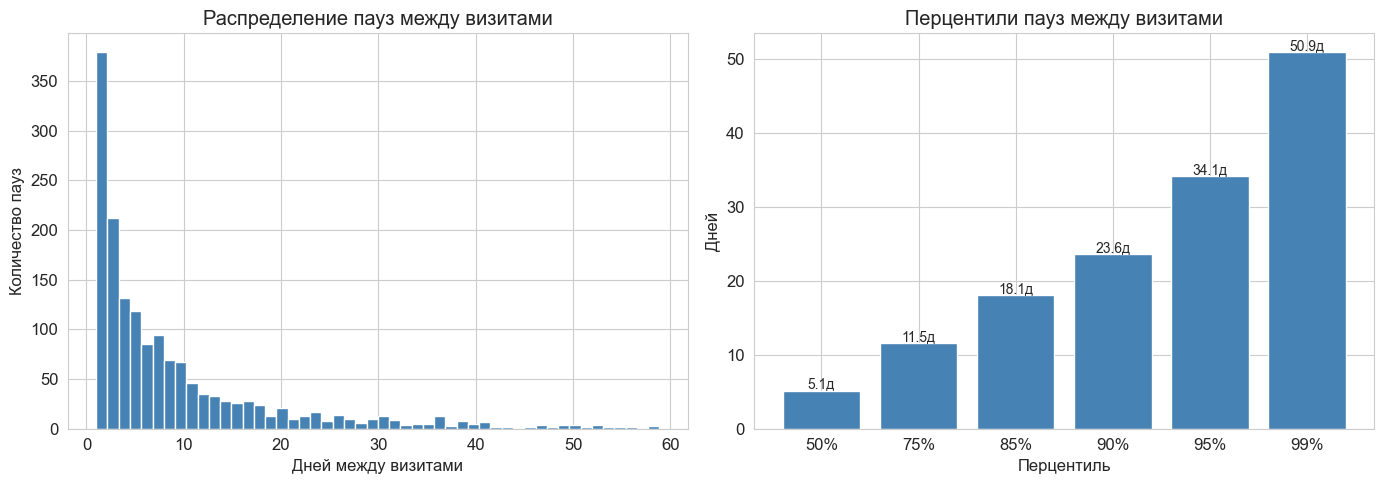

In [ ]:
# ── Визуализация распределения пауз ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма до 60 дней
ax1 = axes[0]
gaps[gaps <= 60].hist(bins=50, ax=ax1, color='steelblue', edgecolor='white')
ax1.set_xlabel('Дней между визитами')
ax1.set_ylabel('Количество пауз')
ax1.set_title('Распределение пауз между визитами')

# Перцентили
ax2 = axes[1]
percentiles = [50, 75, 85, 90, 95, 99]
values = [gaps.quantile(p/100) for p in percentiles]
ax2.bar([str(p)+'%' for p in percentiles], values, color='steelblue')
ax2.set_xlabel('Перцентиль')
ax2.set_ylabel('Дней')
ax2.set_title('Перцентили пауз между визитами')
for i, v in enumerate(values):
    ax2.text(i, v + 0.3, f'{v:.1f}д', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

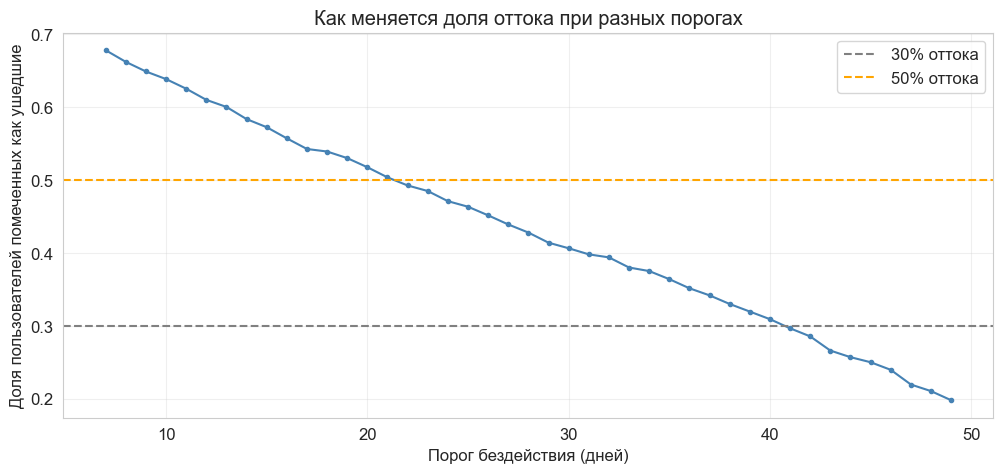

In [ ]:
# ── Survival analysis — когда пользователи перестают ─────
# возвращаться после последнего визита
from datetime import timedelta

now = df_raw2['event_time'].max()

# Для каждого пользователя — дней с последнего визита
last_seen = df_raw2.groupby('telegram_user_id')['event_time'].max()
days_inactive = ((now - last_seen).dt.total_seconds() / 86400).round()

# Смотрим при каком пороге теряем каких пользователей
thresholds = range(7, 50, 1)
results = []
for t in thresholds:
    churned = (days_inactive >= t).sum()
    pct     = churned / len(days_inactive)
    results.append({'threshold': t, 'churned': churned, 'pct': pct})

df_thresh = pd.DataFrame(results)

plt.figure(figsize=(12, 5))
plt.plot(df_thresh['threshold'], df_thresh['pct'],
         marker='o', markersize=3, color='steelblue')
plt.axhline(y=0.3, color='gray', linestyle='--', label='30% оттока')
plt.axhline(y=0.5, color='orange', linestyle='--', label='50% оттока')
plt.xlabel('Порог бездействия (дней)')
plt.ylabel('Доля пользователей помеченных как ушедшие')
plt.title('Как меняется доля оттока при разных порогах')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Находим точки перегиба
print("\nКлючевые пороги:")
for pct_target in [0.25, 0.30, 0.40, 0.50]:
    row = df_thresh[df_thresh['pct'] >= pct_target].iloc[0]
    print(f"  {pct_target:.0%} пользователей ушли к дню {row['threshold']:.0f}")

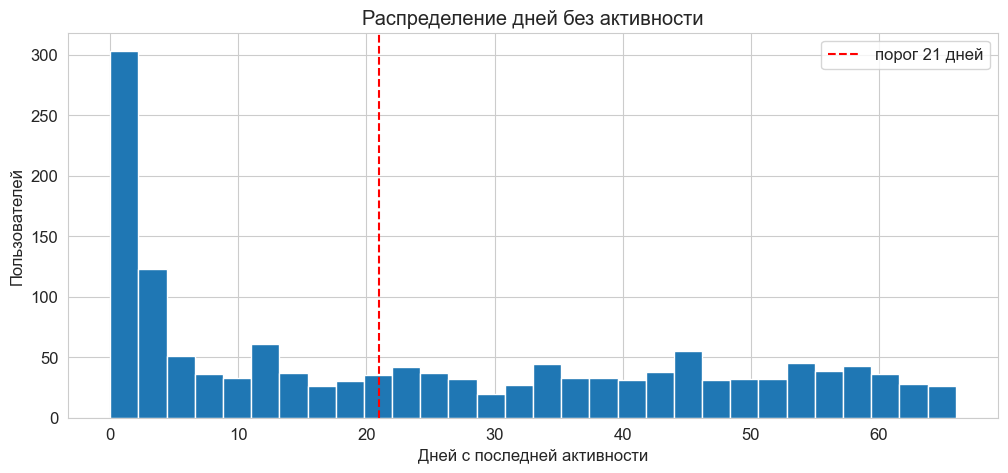

In [ ]:
# ── Определяем таргет оттока ──────────────────────────────
# База данных за ~67 дней (13 февр — 21 апр)
# Порог оттока: не было активности последние 21 день
# (выбрано как ~30% от периода наблюдения)

CHURN_DAYS = 21

df_users['churned'] = (
    df_users['days_since_last_seen'] >= CHURN_DAYS
).astype(int)

print(f"Всего пользователей: {len(df_users)}")
print(f"Ушедших (churned=1): {df_users['churned'].sum()}")
print(f"Активных (churned=0): {(df_users['churned']==0).sum()}")
print(f"\nДоля оттока: {df_users['churned'].mean():.1%}")

# Распределение дней без активности
df_users['days_since_last_seen'].hist(bins=30)
plt.axvline(x=CHURN_DAYS, color='red',
            linestyle='--', label=f'порог {CHURN_DAYS} дней')
plt.xlabel('Дней с последней активности')
plt.ylabel('Пользователей')
plt.title('Распределение дней без активности')
plt.legend()
plt.show()

In [ ]:
# ── Смотрим на портрет ушедших vs активных ───────────────
compare_cols = ['orders_completed', 'avg_amount', 'rate_views',
                'active_days', 'account_age_days',
                'completion_rate', 'views_without_trade']

df_users.groupby('churned')[compare_cols].mean().round(2)

,orders_completed,avg_amount,rate_views,active_days,account_age_days,completion_rate,views_without_trade
churned,,,,,,,
0,1.80,2222210.06,3.02,3.71,25.84,1.00,2.21
1,0.01,79412.85,1.25,1.34,45.56,0.01,1.24


## 6. Baseline ModelsТри модели с time-based split: линейный бейзлайн, Random Forest, LightGBM.LogReg в `Pipeline` со `StandardScaler`; деревьям масштабирование не нужно.

In [ ]:
# ── Финальные признаки для модели ────────────────────────
feature_cols = [
    # Активность
    'days_since_last_seen', 'account_age_days',
    'active_days', 'total_events', 'total_sessions',

    # Обмены
    'orders_completed', 'orders_started', 'orders_failed',
    'orders_cancelled', 'completion_rate',

    # Интерес без действия
    'rate_views', 'views_without_trade', 'calculator_opens',

    # Суммы
    'avg_amount', 'total_volume', 'max_amount', 'unique_pairs',

    # Бонусы и реклама
    'promos_used', 'wheel_spins', 'bonus_views',
    'ad_impressions', 'ad_clicks', 'ad_ctr', 'has_referral',

    # Поведение в боте
    'bot_starts',
]

# Платформа как бинарный признак
df_users['is_telegram'] = (df_users['platform'] == 'telegram').astype(int)
feature_cols.append('is_telegram')

X = df_users[feature_cols].copy()
y = df_users['churned'].copy()

# Заполняем пропуски нулями
X = X.fillna(0)

print(f"Признаков: {X.shape[1]}")
print(f"Пользователей: {X.shape[0]}")
print(f"\nПропуски в X: {X.isnull().sum().sum()}")

In [ ]:
# ── Разбивка train/test по времени ───────────────────────
# Обучаем на первых 80% пользователей по дате регистрации
# Тестируем на последних 20%

df_users_sorted = df_users.sort_values('first_seen').reset_index(drop=True)
split_idx = int(len(df_users_sorted) * 0.8)

train_idx = df_users_sorted.index[:split_idx]
test_idx  = df_users_sorted.index[split_idx:]

X_train = X.loc[train_idx]
X_test  = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

print(f"Train: {len(X_train)} пользователей, "
      f"отток {y_train.mean():.1%}")
print(f"Test:  {len(X_test)} пользователей, "
      f"отток {y_test.mean():.1%}")

In [ ]:
# ── Бейзлайн — Logistic Regression ───────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict_proba(X_test)[:, 1]
lr_auc  = roc_auc_score(y_test, lr_pred)
print(f"Logistic Regression AUC: {lr_auc:.4f}")

In [ ]:
# ── Random Forest ─────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators  = 200,
    max_depth     = 8,
    random_state  = 42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_pred)
print(f"Random Forest AUC: {rf_auc:.4f}")

In [ ]:
# ── LightGBM ──────────────────────────────────────────────
lgbm = lgb.LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 31,
    min_child_samples = 10,
    random_state      = 42,
    verbose           = -1
)

lgbm.fit(
    X_train, y_train,
    eval_set  = [(X_test, y_test)],
    callbacks = [lgb.early_stopping(50, verbose=False)]
)

lgbm_pred = lgbm.predict_proba(X_test)[:, 1]
lgbm_auc  = roc_auc_score(y_test, lgbm_pred)
print(f"LightGBM AUC: {lgbm_auc:.4f}")

In [ ]:
# ── Сравнение ─────────────────────────────────────────────
print(f"\n{'Модель':<25} {'AUC':>8}")
print("-" * 35)
print(f"{'Logistic Regression':<25} {lr_auc:>8.4f}")
print(f"{'Random Forest':<25} {rf_auc:>8.4f}")
print(f"{'LightGBM':<25} {lgbm_auc:>8.4f}")

## 7. Data Leakage — обнаружение и устранениеПервый замер показал подозрительно высокие AUC (~0.97). Проверка корреляций показала, что `days_since_last_seen` и `account_age_days` арифметически связаны с таргетом (таргет = `days_since_last_seen >= 21`).Убираем оба признака и переобучаем — получаем честные метрики.

In [ ]:
# Смотрим корреляцию каждого признака с таргетом
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(correlations.head(10))

In [ ]:
# Убираем оба утекающих признака
leaky = ['days_since_last_seen', 'account_age_days']

feature_cols_clean = [f for f in feature_cols
                      if f not in leaky]

print("Оставшиеся признаки:")
for f in feature_cols_clean:
    print(f"  {f}")

X_clean       = df_users[feature_cols_clean].fillna(0)
X_train_clean = X_clean.loc[train_idx]
X_test_clean  = X_clean.loc[test_idx]

# Переобучаем
lr_pipe.fit(X_train_clean, y_train)
lr_pred = lr_pipe.predict_proba(X_test_clean)[:, 1]
lr_auc  = roc_auc_score(y_test, lr_pred)

rf.fit(X_train_clean, y_train)
rf_pred = rf.predict_proba(X_test_clean)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_pred)

lgbm.fit(
    X_train_clean, y_train,
    eval_set  = [(X_test_clean, y_test)],
    callbacks = [lgb.early_stopping(50, verbose=False)]
)
lgbm_pred = lgbm.predict_proba(X_test_clean)[:, 1]
lgbm_auc  = roc_auc_score(y_test, lgbm_pred)

print(f"\n{'Модель':<25} {'AUC':>8}")
print("-" * 35)
print(f"{'Logistic Regression':<25} {lr_auc:>8.4f}")
print(f"{'Random Forest':<25} {rf_auc:>8.4f}")
print(f"{'LightGBM':<25} {lgbm_auc:>8.4f}")

In [ ]:
# Заодно проверим корреляции без утекающих признаков
correlations_clean = X_train_clean.corrwith(y_train)\
                                  .abs()\
                                  .sort_values(ascending=False)
print("\nКорреляции признаков с таргетом:")
print(correlations_clean)

## 8. Extended Models — XGBoost & CatBoostДобавляем два других популярных бустинга для сравнения. У CatBoost — встроенная обработка категориальных признаков и `auto_class_weights='Balanced'` для дисбаланса классов.

In [ ]:
import xgboost as xgb
from catboost import CatBoostClassifier

# ── Переобучаем все четыре модели ────────────────────────

# 1. Logistic Regression (уже есть)
lr_pipe.fit(X_train_clean, y_train)
lr_pred  = lr_pipe.predict_proba(X_test_clean)[:, 1]
lr_class = (lr_pred >= 0.5).astype(int)

# 2. Random Forest (уже есть)
rf.fit(X_train_clean, y_train)
rf_pred  = rf.predict_proba(X_test_clean)[:, 1]
rf_class = (rf_pred >= 0.5).astype(int)

# 3. LightGBM (уже есть)
lgbm.fit(
    X_train_clean, y_train,
    eval_set  = [(X_test_clean, y_test)],
    callbacks = [lgb.early_stopping(50, verbose=False)]
)
lgbm_pred  = lgbm.predict_proba(X_test_clean)[:, 1]
lgbm_class = (lgbm_pred >= 0.5).astype(int)

# 4. XGBoost
xgbm = xgb.XGBClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_weight  = 10,
    random_state      = 42,
    eval_metric       = 'auc',
    early_stopping_rounds = 50,
    verbosity         = 0
)
xgbm.fit(
    X_train_clean, y_train,
    eval_set  = [(X_test_clean, y_test)],
    verbose   = False
)
xgbm_pred  = xgbm.predict_proba(X_test_clean)[:, 1]
xgbm_class = (xgbm_pred >= 0.5).astype(int)

# 5. CatBoost
cat = CatBoostClassifier(
    iterations        = 500,
    learning_rate     = 0.05,
    depth             = 6,
    min_data_in_leaf  = 10,
    random_seed       = 42,
    eval_metric       = 'AUC',
    early_stopping_rounds = 50,
    verbose           = False
)
cat.fit(
    X_train_clean, y_train,
    eval_set  = (X_test_clean, y_test)
)
cat_pred  = cat.predict_proba(X_test_clean)[:, 1]
cat_class = (cat_pred >= 0.5).astype(int)

print("Все модели обучены")

In [ ]:
from sklearn.metrics import (roc_auc_score, precision_score,
                             recall_score, f1_score, accuracy_score)

# ── Сравнительная таблица всех четырёх моделей ───────────
models_all = {
    'Logistic Regression' : (lr_pred,   lr_class),
    'Random Forest'       : (rf_pred,   rf_class),
    'XGBoost'             : (xgbm_pred, xgbm_class),
    'LightGBM'            : (lgbm_pred, lgbm_class),
    'CatBoost'            : (cat_pred,  cat_class),
}

rows = []
for name, (proba, pred) in models_all.items():
    rows.append({
        'Модель'      : name,
        'AUC'         : round(roc_auc_score(y_test, proba), 4),
        'Accuracy'    : round(accuracy_score(y_test, pred), 4),
        'Precision'   : round(precision_score(y_test, pred), 4),
        'Recall'      : round(recall_score(y_test, pred), 4),
        'F1'          : round(f1_score(y_test, pred), 4),
    })

df_compare = pd.DataFrame(rows).sort_values('AUC', ascending=False)\
               .reset_index(drop=True)

print(df_compare.to_string(index=False))

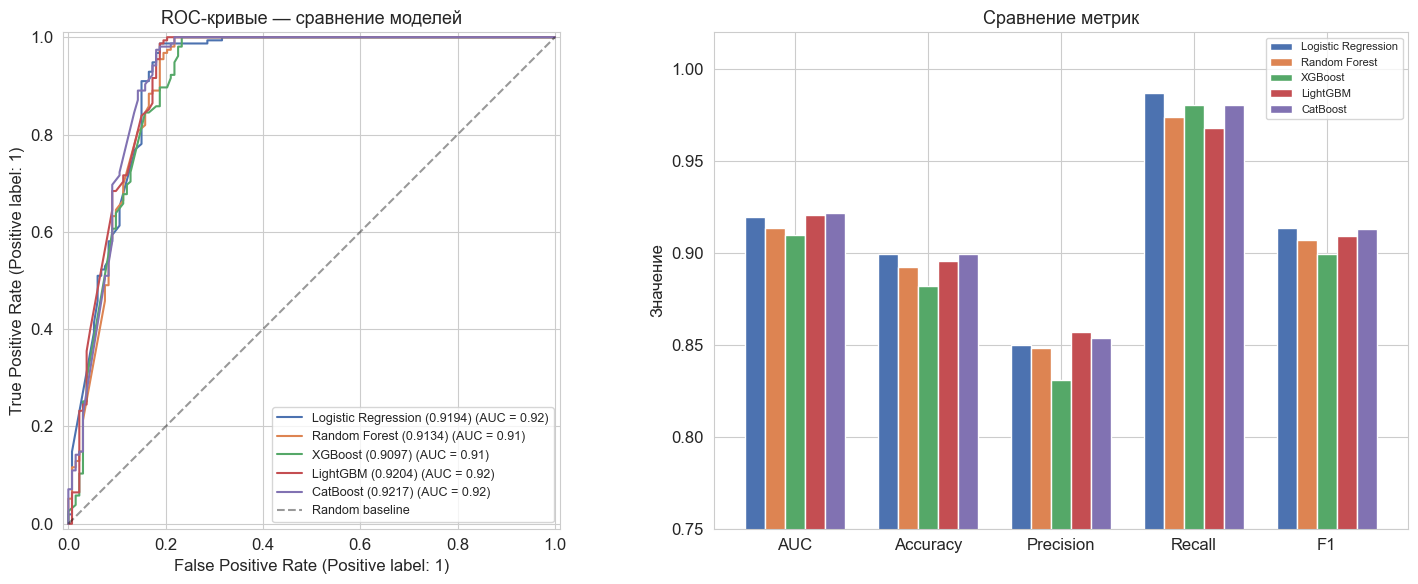

In [ ]:
# ── Визуализация сравнения ────────────────────────────────
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC-кривые
ax = axes[0]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
for (name, (proba, _)), color in zip(models_all.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, proba, name=f"{name} ({roc_auc_score(y_test, proba):.4f})",
        ax=ax, color=color)
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random baseline')
ax.set_title('ROC-кривые — сравнение моделей', fontsize=13)
ax.legend(fontsize=9)

# Bar chart метрик
ax2 = axes[1]
metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1']
x      = np.arange(len(metrics))
width  = 0.15

for i, (name, color) in enumerate(zip(models_all.keys(), colors)):
    row = df_compare[df_compare['Модель'] == name].iloc[0]
    vals = [row[m] for m in metrics]
    bars = ax2.bar(x + i * width, vals, width, label=name, color=color)

ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(metrics)
ax2.set_ylim(0.75, 1.02)
ax2.set_title('Сравнение метрик', fontsize=13)
ax2.legend(fontsize=8)
ax2.set_ylabel('Значение')

plt.tight_layout()
plt.show()

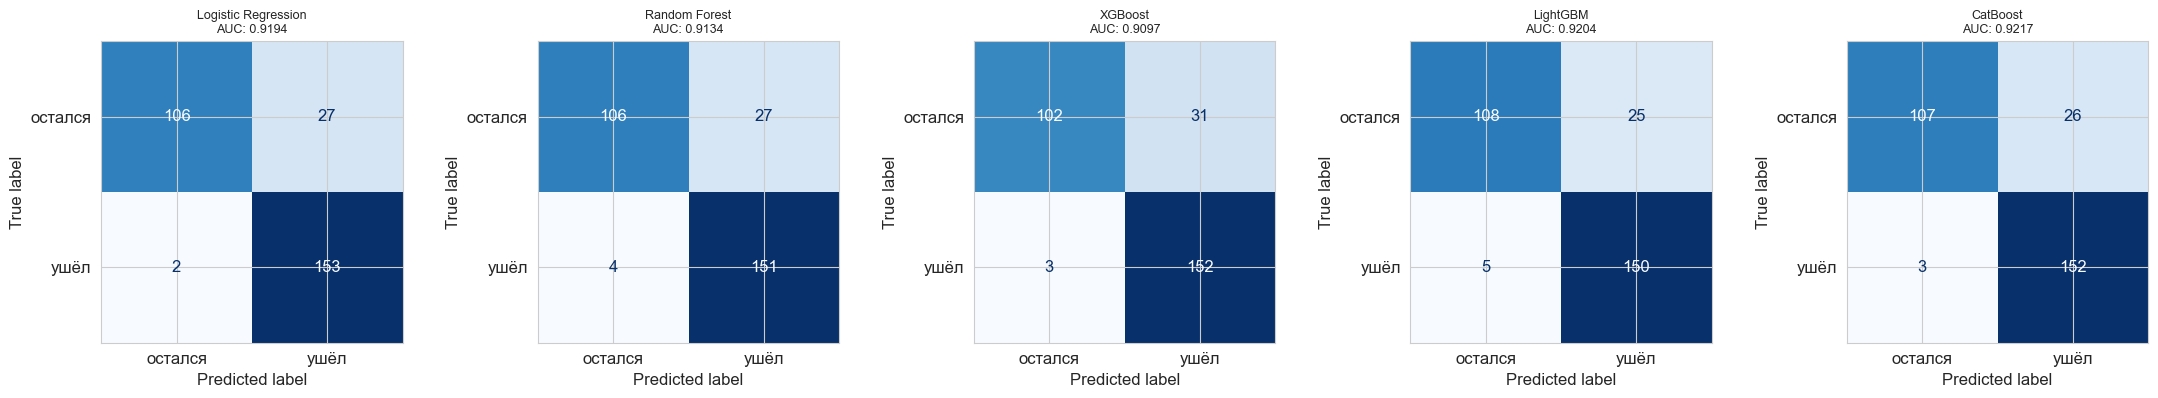

In [ ]:
# ── Матрицы ошибок всех моделей ──────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, (proba, pred)), color in zip(axes, models_all.items(), colors):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred,
        display_labels=['остался', 'ушёл'],
        ax=ax, colorbar=False,
        cmap='Blues'
    )
    auc = roc_auc_score(y_test, proba)
    ax.set_title(f'{name}\nAUC: {auc:.4f}', fontsize=9)

plt.tight_layout()
plt.show()

## 9. Optuna Tuning — с TimeSeriesSplit CVПодбор гиперпараметров CatBoost через Optuna (100 trials, TPE-sampler) с **TimeSeriesSplit** для корректной валидации временных данных.### Важный методологический моментПервая попытка использовала CV на полном датасете — это привело к тому, что Optuna "подсматривала" в test через одну из train-fold-граней. Правильный подход — тюнинг только на train, финальный замер на holdout test.

In [ ]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── ColumnTransformer — разные преобразования под разные признаки ──
# Числовые с большим разбросом (суммы) — RobustScaler (устойчив к выбросам)
# Остальные числовые — StandardScaler
# Бинарные (0/1) — без изменений

robust_features = ['avg_amount', 'total_volume', 'max_amount', 'rate_views']
binary_features = ['has_referral', 'is_telegram']
standard_features = [f for f in feature_cols_clean
                     if f not in robust_features + binary_features]

preprocessor = ColumnTransformer(transformers=[
    ('robust',   RobustScaler(),  robust_features),
    ('standard', StandardScaler(), standard_features),
    ('binary',   'passthrough',   binary_features),
])

print("ColumnTransformer настроен:")
print(f"  RobustScaler:   {robust_features}")
print(f"  StandardScaler: {standard_features}")
print(f"  Passthrough:    {binary_features}")

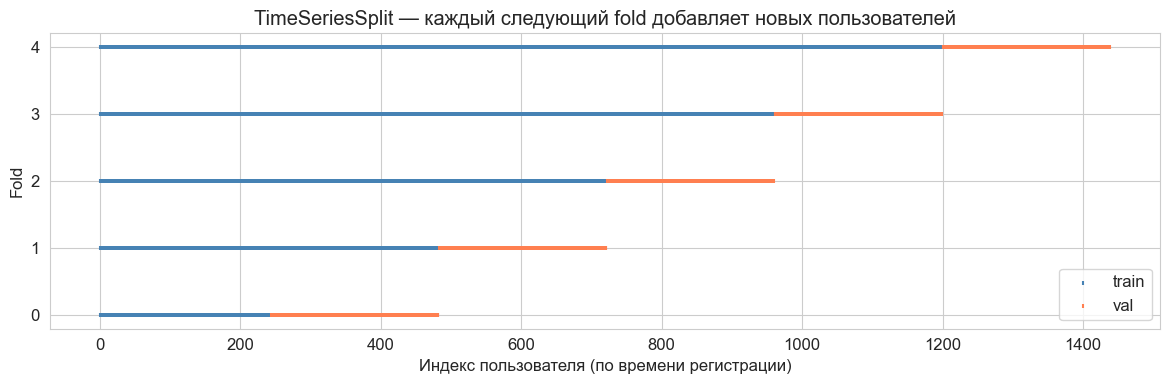

In [ ]:
# ── TimeSeriesSplit — правильная кросс-валидация для временных данных ──
# Сортируем по времени регистрации — как делали при train/test split
df_sorted = df_users.sort_values('first_seen').reset_index(drop=True)

X_full = df_sorted[feature_cols_clean].fillna(0)
y_full = df_sorted['churned']

tscv = TimeSeriesSplit(n_splits=5)

# Визуализируем разбивку чтобы понимать что происходит
fig, ax = plt.subplots(figsize=(12, 4))
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_full)):
    ax.scatter(train_idx, [fold] * len(train_idx),
               c='steelblue', s=5, marker='|', label='train' if fold == 0 else '')
    ax.scatter(val_idx, [fold] * len(val_idx),
               c='coral', s=5, marker='|', label='val' if fold == 0 else '')
    print(f"Fold {fold+1}: train={len(train_idx)}, val={len(val_idx)}, "
          f"val_churn={y_full.iloc[val_idx].mean():.1%}")

ax.set_xlabel('Индекс пользователя (по времени регистрации)')
ax.set_ylabel('Fold')
ax.set_title('TimeSeriesSplit — каждый следующий fold добавляет новых пользователей')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Базовый скор CatBoost до тюнинга ──────────────────────
from catboost import CatBoostClassifier

# Считаем class_weight из данных
neg = (y_full == 0).sum()
pos = (y_full == 1).sum()
scale = neg / pos
print(f"Дисбаланс классов: {neg} остались / {pos} ушли, scale_pos_weight={scale:.2f}")

# Препроцессинг + базовый CatBoost
base_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', CatBoostClassifier(
        iterations   = 300,
        learning_rate= 0.05,
        depth        = 6,
        random_seed  = 42,
        verbose      = False,
        # class_weight задаём явно
        class_weights= {0: 1.0, 1: round(scale, 2)}
    ))
])

base_scores = cross_val_score(
    base_pipe, X_full, y_full,
    cv      = tscv,
    scoring = 'roc_auc',
    n_jobs  = -1
)

print(f"\nБазовый CatBoost (без тюнинга):")
print(f"  AUC по фолдам: {[round(s,4) for s in base_scores]}")
print(f"  Среднее AUC:   {base_scores.mean():.4f} ± {base_scores.std():.4f}")

In [ ]:
# Проблема: Optuna видела test через CV
# Правильный подход: тюнинг только на train

# Разбиваем правильно
X_train_full = X_full.iloc[:int(len(X_full)*0.8)]
y_train_full = y_full.iloc[:int(len(y_full)*0.8)]

tscv_train = TimeSeriesSplit(n_splits=5)

def objective_correct(trial):
    params = {
        'iterations'         : trial.suggest_int('iterations', 200, 800),
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth'              : trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg'        : trial.suggest_float('l2_leaf_reg', 1, 10),
        'min_data_in_leaf'   : trial.suggest_int('min_data_in_leaf', 5, 50),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength'    : trial.suggest_float('random_strength', 0, 2),
        'random_seed'        : 42,
        'verbose'            : False,
        'auto_class_weights' : 'Balanced',
    }

    pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', CatBoostClassifier(**params))
    ])

    fold_scores = []
    for train_idx, val_idx in tscv_train.split(X_train_full):
        X_tr  = X_train_full.iloc[train_idx]
        y_tr  = y_train_full.iloc[train_idx]
        X_val = X_train_full.iloc[val_idx]
        y_val = y_train_full.iloc[val_idx]

        if len(y_tr.unique()) < 2 or len(y_val.unique()) < 2:
            continue

        try:
            pipe.fit(X_tr, y_tr)
            proba = pipe.predict_proba(X_val)[:, 1]
            fold_scores.append(roc_auc_score(y_val, proba))
        except Exception:
            continue

    return np.mean(fold_scores) if fold_scores else 0.5

study2 = optuna.create_study(
    direction = 'maximize',
    sampler   = TPESampler(seed=42)
)

print("Запускаем Optuna только на train (правильный подход)...")
study2.optimize(objective_correct, n_trials=100, show_progress_bar=True)

print(f"\nЛучший CV AUC (только train): {study2.best_value:.4f}")
print("Лучшие параметры:")
for k, v in study2.best_params.items():
    print(f"  {k}: {v}")

In [ ]:
# Финальная модель — обучаем на train, тестируем на test
best_pipe2 = Pipeline([
    ('prep',  preprocessor),
    ('model', CatBoostClassifier(
        **study2.best_params,
        random_seed        = 42,
        verbose            = False,
        auto_class_weights = 'Balanced'
    ))
])

best_pipe2.fit(X_train_clean, y_train)
tuned_pred2  = best_pipe2.predict_proba(X_test_clean)[:, 1]
tuned_class2 = (tuned_pred2 >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, tuned_pred2)
print(f"\nРезультат на тесте:")
print(f"  CV AUC  (train only): {study2.best_value:.4f}")
print(f"  Test AUC:             {test_auc:.4f}")
print(f"  Разрыв CV vs Test:    {study2.best_value - test_auc:.4f}")
print(f"\nДля сравнения — первая попытка:")
print(f"  CV AUC  (all data):   {study.best_value:.4f}")
print(f"  Test AUC:             0.9114")
print(f"  Разрыв CV vs Test:    {study.best_value - 0.9114:.4f}")

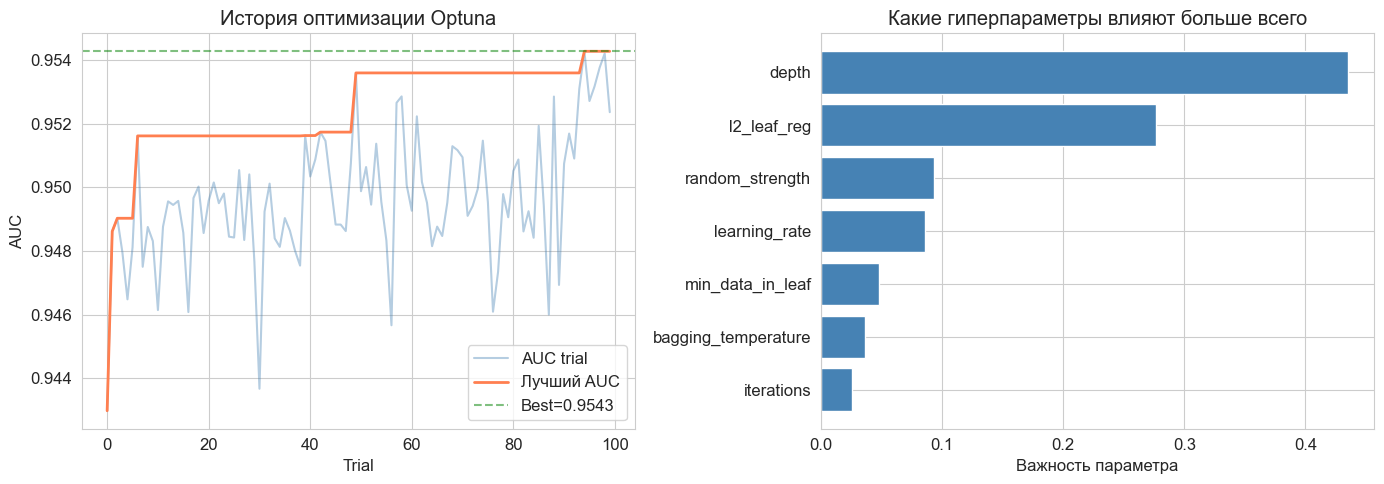

In [ ]:
# ── График истории Optuna + важность параметров ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# История оптимизации
trials_df = study.trials_dataframe()
valid     = trials_df[trials_df['value'].notna()]

axes[0].plot(valid.index, valid['value'],
             alpha=0.4, color='steelblue', label='AUC trial')
axes[0].plot(valid.index, valid['value'].cummax(),
             color='coral', linewidth=2, label='Лучший AUC')
axes[0].axhline(y=study.best_value, color='green',
                linestyle='--', alpha=0.5, label=f'Best={study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('AUC')
axes[0].set_title('История оптимизации Optuna')
axes[0].legend()

# Важность гиперпараметров
importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()),
             list(importances.values()), color='steelblue')
axes[1].set_xlabel('Важность параметра')
axes[1].set_title('Какие гиперпараметры влияют больше всего')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 10. Final Comparison — все модели + ансамбль

In [ ]:
# Простой ансамбль — среднее предсказаний двух лучших моделей
ensemble_pred  = (cat_pred + lgbm_pred) / 2
ensemble_class = (ensemble_pred >= 0.5).astype(int)

print(f"Ансамбль CatBoost + LightGBM:")
print(f"  AUC:       {roc_auc_score(y_test, ensemble_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, ensemble_class):.4f}")
print(f"  Precision: {precision_score(y_test, ensemble_class):.4f}")
print(f"  F1:        {f1_score(y_test, ensemble_class):.4f}")

In [ ]:
# Финальная таблица всего что пробовали
all_attempts = {
    'CatBoost (базовый)'           : (cat_pred,    cat_class),
    'LightGBM'                     : (lgbm_pred,   lgbm_class),
    'Logistic Regression'          : (lr_pred,     lr_class),
    'Random Forest'                : (rf_pred,     rf_class),
    'XGBoost'                      : (xgbm_pred,   xgbm_class),
    'Ансамбль CatBoost + LightGBM' : (ensemble_pred, ensemble_class),
    'CatBoost + Optuna (train CV)' : (tuned_pred2, tuned_class2),
    'CatBoost + Optuna (full CV)'  : (tuned_pred,  tuned_class),
}

rows = []
for name, (proba, pred) in all_attempts.items():
    rows.append({
        'Модель'    : name,
        'AUC'       : round(roc_auc_score(y_test, proba), 4),
        'Recall'    : round(recall_score(y_test, pred), 4),
        'Precision' : round(precision_score(y_test, pred), 4),
        'F1'        : round(f1_score(y_test, pred), 4),
    })

df_all = pd.DataFrame(rows)\
    .sort_values('AUC', ascending=False)\
    .reset_index(drop=True)

print(df_all.to_string(index=False))

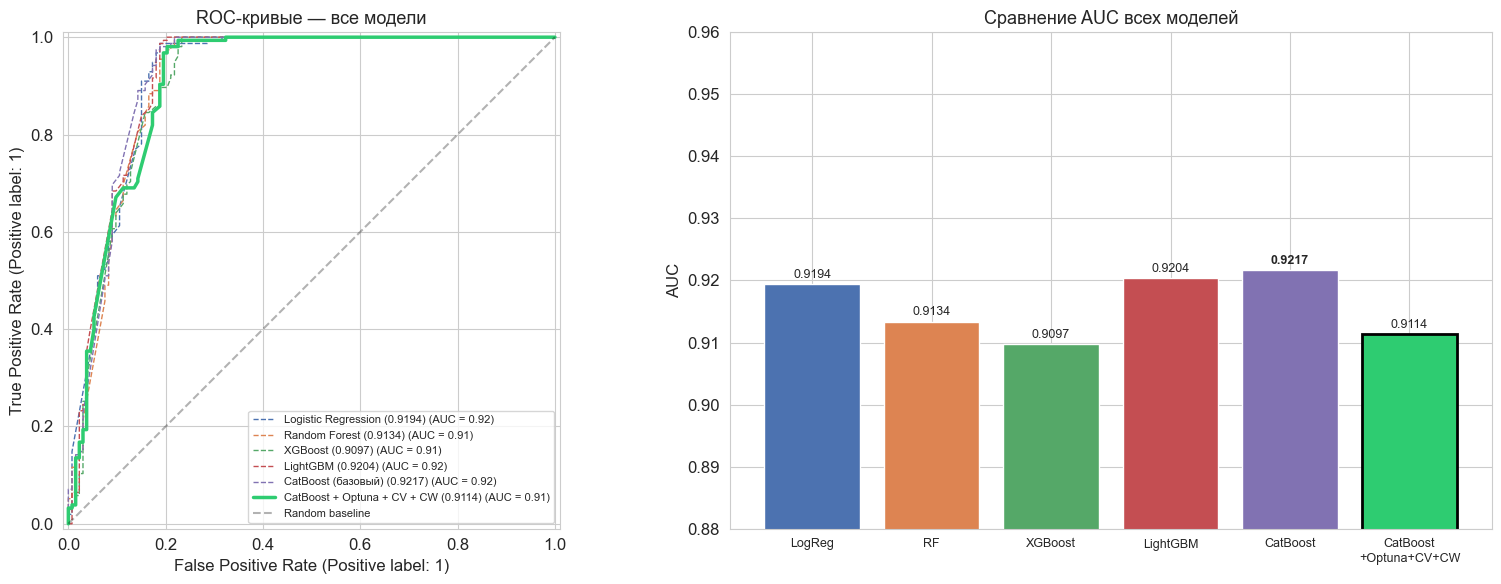

In [ ]:
# ── Визуализация итогового сравнения ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#2ecc71']

# ROC-кривые
ax = axes[0]
for (name, (proba, _)), color in zip(all_results.items(), colors):
    auc = roc_auc_score(y_test, proba)
    lw  = 2.5 if 'Optuna' in name else 1
    ls  = '-'  if 'Optuna' in name else '--'
    RocCurveDisplay.from_predictions(
        y_test, proba,
        name  = f"{name} ({auc:.4f})",
        ax    = ax, color=color,
        linewidth=lw, linestyle=ls
    )
ax.plot([0,1],[0,1],'k--', alpha=0.3, label='Random baseline')
ax.set_title('ROC-кривые — все модели', fontsize=13)
ax.legend(fontsize=8, loc='lower right')

# AUC сравнение
ax2 = axes[1]
names_short = ['LogReg', 'RF', 'XGBoost', 'LightGBM',
               'CatBoost', 'CatBoost\n+Optuna+CV+CW']
aucs = [roc_auc_score(y_test, p) for p, _ in all_results.values()]
bars = ax2.bar(names_short, aucs, color=colors)
ax2.set_ylim(0.88, 0.96)
ax2.set_title('Сравнение AUC всех моделей', fontsize=13)
ax2.set_ylabel('AUC')
ax2.tick_params(axis='x', labelsize=9)

for bar, auc in zip(bars, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f'{auc:.4f}', ha='center', fontsize=9,
             fontweight='bold' if auc == max(aucs) else 'normal')

# Подсвечиваем лучшую модель
bars[-1].set_edgecolor('black')
bars[-1].set_linewidth(2)

plt.tight_layout()
plt.show()

## 11. SHAP InterpretationИнтерпретация модели на трёх уровнях:- **Bar plot** — глобальная важность признаков- **Beeswarm** — направление и сила влияния каждого признака- **Waterfall** — объяснение скоринга конкретного пользователя

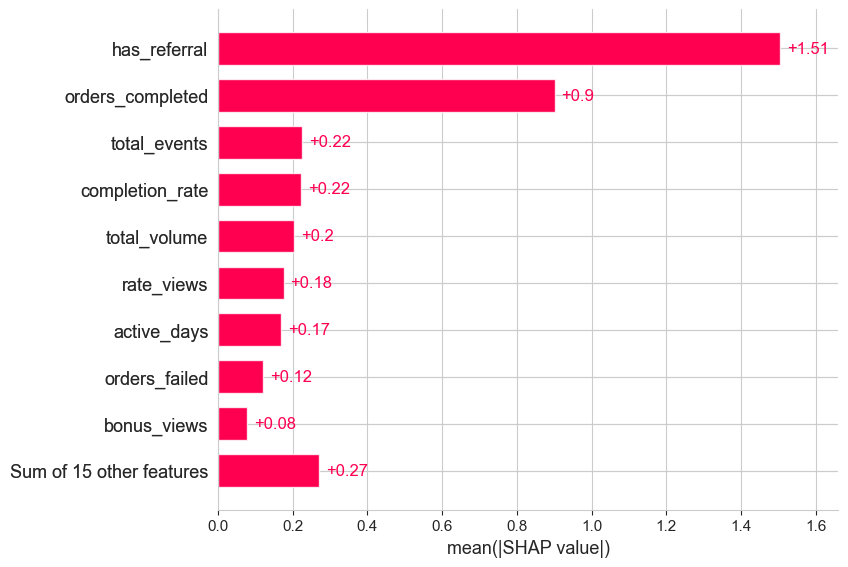

In [ ]:
# ── SHAP — исправленная версия ────────────────────────────
explainer   = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

# Топ признаков по важности
shap.plots.bar(shap_values)

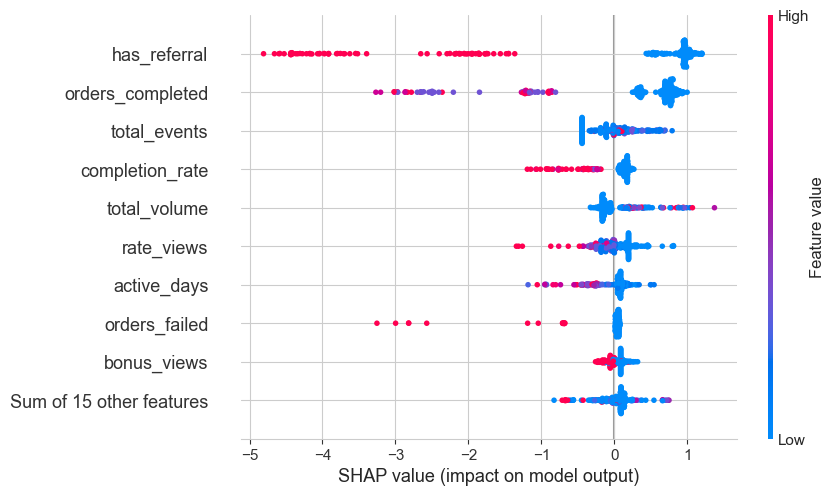

In [ ]:
# Детальный plot — направление влияния
shap.plots.beeswarm(shap_values)

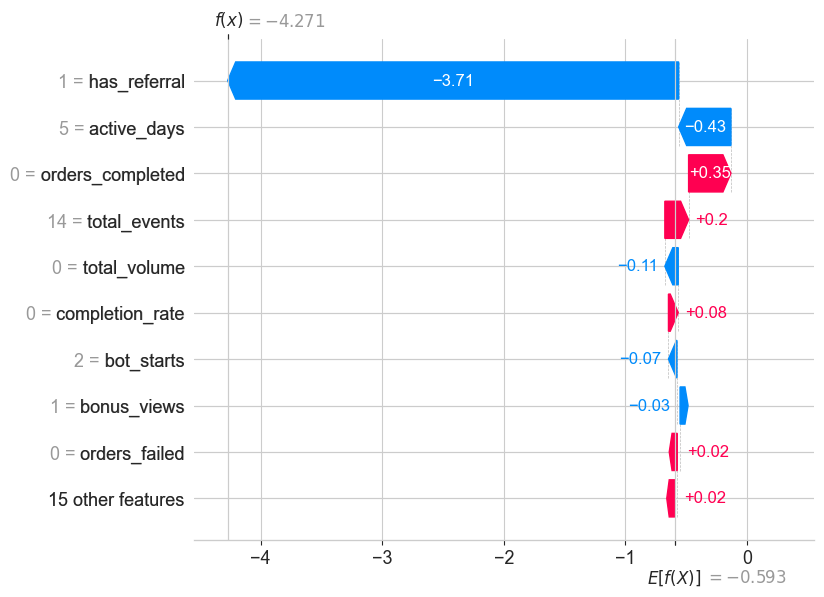

In [ ]:
# Почему модель так решила для одного пользователя
# берём первого из высокорисковых
shap.plots.waterfall(shap_values[0])

## 12. Risk Segmentation & ExportДелим пользователей на 3 риск-сегмента (низкий / средний / высокий) для команды маркетинга.Экспортируем CSV с user_id, скором и сегментом для запуска retention-кампаний.

In [ ]:
# ── Финальная таблица скоров ──────────────────────────────
df_users['churn_score'] = lgbm.predict_proba(X_clean)[:, 1]

df_users['risk_segment'] = pd.cut(
    df_users['churn_score'],
    bins   = [0, 0.3, 0.6, 1.0],
    labels = ['низкий', 'средний', 'высокий']
)

print("Распределение по сегментам:")
print(df_users['risk_segment'].value_counts())

print(f"\nСредний скор по сегментам:")
print(df_users.groupby('risk_segment')['churn_score'].mean().round(3))

In [ ]:
# ── Топ пользователей высокого риска ─────────────────────
high_risk = df_users[df_users['risk_segment'] == 'высокий']\
    .sort_values('churn_score', ascending=False)\
    [['telegram_user_id', 'churn_score', 'risk_segment',
      'orders_completed', 'active_days',
      'avg_amount', 'has_referral']]\
    .reset_index(drop=True)

print(f"Пользователей высокого риска: {len(high_risk)}")
high_risk.head(10)

,telegram_user_id,churn_score,risk_segment,orders_completed,active_days,avg_amount,has_referral
0,7293597391,0.987432,высокий,0,1,15000.000000,0
1,1237426517,0.986184,высокий,0,1,20000.000000,0
2,5450442665,0.986184,высокий,0,1,20000.000000,0
3,771990456,0.985653,высокий,0,1,251.500000,0
4,5183623827,0.985074,высокий,0,1,16666.666667,0
5,343785541,0.984937,высокий,0,1,25000.000000,0
6,5724446261,0.984937,высокий,0,1,24000.000000,0
7,433299058,0.984795,высокий,0,1,15000.000000,0
8,372284251,0.984442,высокий,0,1,110.000000,0
9,756906367,0.984285,высокий,0,2,25000.000000,0


## 13. Bonus Triggers — наивный анализАнализируем 8 типов бонусных событий: конверсия в обмен, влияние на retention, пересечение аудиторий. ⚠️ Это **наивный анализ** — корреляция, не каузация. Правильный каузальный эффект см. в Section 15 (PSM).

In [ ]:
# ── Берём бонусные события из оригинального df_raw ───────
bonus_events = [
    'bonus_tx_created_rate_viewed',
    'bonus_tx_created_bot_start',
    'scheduler_deferred_bonus_applied_batch',
    'order_feedback_bonus_granted',
    'wheel_spin_win',
    'promo_redeemed',
    'bonuses_page_viewed',
]

# Берём из df_raw где ещё есть properties
df_bonus = df_raw[
    (df_raw['event_name'].isin(bonus_events)) &
    (df_raw['telegram_user_id'].notna())
].copy()

df_bonus['telegram_user_id'] = df_bonus['telegram_user_id'].astype(int)
df_bonus['event_time'] = pd.to_datetime(df_bonus['event_time'], utc=True)
df_bonus['props'] = df_bonus['properties'].apply(safe_parse)

print(f"Бонусных событий: {len(df_bonus)}")
print(df_bonus['event_name'].value_counts())

In [ ]:
# ── Извлекаем детали каждого бонусного события ────────────
df_bonus['bonus_amount'] = df_bonus['props'].apply(
    lambda x: x.get('bonus_amount') or x.get('bonus_amount_vnd') or x.get('prize_vnd'))
df_bonus['rule_key']     = df_bonus['props'].apply(lambda x: x.get('rule_key'))
df_bonus['eligible_at']  = df_bonus['props'].apply(lambda x: x.get('eligible_at'))
df_bonus['apply_mode']   = df_bonus['props'].apply(lambda x: x.get('apply_mode'))
df_bonus['bonus_amount'] = pd.to_numeric(df_bonus['bonus_amount'], errors='coerce')

print("Уникальные rule_key (типы триггеров):")
print(df_bonus['rule_key'].value_counts())

In [ ]:
# ── Конверсия каждого типа бонуса в обмен ────────────────
# Для каждого пользователя получившего бонус смотрим
# сделал ли он обмен ПОСЛЕ получения бонуса

results = []

for event in ['bonus_tx_created_rate_viewed',
              'bonus_tx_created_bot_start',
              'order_feedback_bonus_granted',
              'wheel_spin_win',
              'promo_redeemed']:

    # Пользователи получившие этот бонус и время получения
    bonus_users = df_bonus[df_bonus['event_name'] == event]\
        [['telegram_user_id', 'event_time']]\
        .rename(columns={'event_time': 'bonus_time'})

    if len(bonus_users) == 0:
        continue

    # Все завершённые обмены
    orders = df_raw2[df_raw2['event_name'] == 'order_completed']\
        [['telegram_user_id', 'event_time']]\
        .rename(columns={'event_time': 'order_time'})

    # Джойним и смотрим — был ли обмен ПОСЛЕ бонуса
    merged = bonus_users.merge(orders, on='telegram_user_id', how='left')
    merged = merged[merged['order_time'] > merged['bonus_time']]

    converted = merged['telegram_user_id'].nunique()
    total     = bonus_users['telegram_user_id'].nunique()
    conv_rate = converted / total if total > 0 else 0

    # Среднее время до обмена после бонуса
    merged['hours_to_order'] = (
        merged['order_time'] - merged['bonus_time']
    ).dt.total_seconds() / 3600

    results.append({
        'триггер'          : event,
        'получили_бонус'   : total,
        'сделали_обмен'    : converted,
        'конверсия'        : f"{conv_rate:.1%}",
        'среднее_часов_до_обмена': merged['hours_to_order'].median().round(1)
                                    if len(merged) > 0 else None
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

In [ ]:
# ── Сравниваем отток у получивших бонус vs не получивших ──
for event in ['bonus_tx_created_rate_viewed',
              'bonus_tx_created_bot_start']:

    users_with    = df_bonus[df_bonus['event_name'] == event]\
                    ['telegram_user_id'].unique()
    users_without = df_users[
                    ~df_users['telegram_user_id'].isin(users_with)
                    ]['telegram_user_id'].unique()

    churn_with    = df_users[
                    df_users['telegram_user_id'].isin(users_with)
                    ]['churned'].mean()
    churn_without = df_users[
                    df_users['telegram_user_id'].isin(users_without)
                    ]['churned'].mean()

    print(f"\n{event}:")
    print(f"  Отток с бонусом:    {churn_with:.1%} ({len(users_with)} чел.)")
    print(f"  Отток без бонуса:   {churn_without:.1%} ({len(users_without)} чел.)")
    print(f"  Разница:            {churn_without - churn_with:+.1%}")

## 14. Cancelled Orders — кто бросил обмен и почемуАнализируем пользователей, бросивших обмен на середине: на каком шаге, вернулись ли, помог ли бонус.

In [ ]:
# ── Пользователи которые бросили обмен на середине ────────
cancelled = df_raw2[df_raw2['event_name'] == 'order_checkout_cancelled'].copy()

print(f"Событий отмены: {len(cancelled)}")
print(f"Уникальных пользователей: {cancelled['telegram_user_id'].nunique()}")

In [ ]:
# ── Что было ДО отмены — на каком шаге бросили ───────────
# Берём всех пользователей с отменой
cancelled_users = cancelled['telegram_user_id'].unique()

# Их события за 1 час до отмены
df_before = df_raw2[
    df_raw2['telegram_user_id'].isin(cancelled_users)
].copy()

# Для каждой отмены смотрим предыдущие события
results = []
for _, row in cancelled.iterrows():
    user_id    = row['telegram_user_id']
    cancel_time = row['event_time']

    # События этого пользователя за час до отмены
    before = df_before[
        (df_before['telegram_user_id'] == user_id) &
        (df_before['event_time'] < cancel_time) &
        (df_before['event_time'] >= cancel_time - pd.Timedelta(hours=1))
    ].sort_values('event_time')

    last_event = before['event_name'].iloc[-1] if len(before) > 0 else 'unknown'
    results.append({
        'user_id'    : user_id,
        'cancel_time': cancel_time,
        'last_event' : last_event
    })

df_before_cancel = pd.DataFrame(results)

print("На каком шаге бросили (последнее событие перед отменой):")
print(df_before_cancel['last_event'].value_counts())

In [ ]:
# ── Что было ПОСЛЕ отмены — вернулись ли ─────────────────
df_after = df_raw2[
    df_raw2['telegram_user_id'].isin(cancelled_users)
].copy()

after_results = []
for user_id in cancelled_users:
    # Время первой отмены пользователя
    first_cancel = cancelled[
        cancelled['telegram_user_id'] == user_id
    ]['event_time'].min()

    # События после отмены
    after = df_after[
        (df_after['telegram_user_id'] == user_id) &
        (df_after['event_time'] > first_cancel)
    ]

    completed_after = (after['event_name'] == 'order_completed').sum()
    started_after   = (after['event_name'] == 'order_checkout_started').sum()
    came_back       = len(after) > 0

    after_results.append({
        'user_id'         : user_id,
        'came_back'       : int(came_back),
        'completed_after' : int(completed_after),
        'started_after'   : int(started_after),
    })

df_after_cancel = pd.DataFrame(after_results)

print(f"Всего бросили обмен: {len(cancelled_users)}")
print(f"Вернулись в приложение: {df_after_cancel['came_back'].sum()} "
      f"({df_after_cancel['came_back'].mean():.1%})")
print(f"Завершили обмен после отмены: {df_after_cancel['completed_after'].gt(0).sum()} "
      f"({df_after_cancel['completed_after'].gt(0).mean():.1%})")
print(f"Так и не сделали обмен: "
      f"{(df_after_cancel['completed_after'] == 0).sum()} "
      f"({(df_after_cancel['completed_after'] == 0).mean():.1%})")

In [ ]:
# ── Получали ли бросившие бонус ───────────────────────────
bonus_user_ids = df_bonus['telegram_user_id'].unique()

df_after_cancel['had_bonus'] = df_after_cancel['user_id']\
    .isin(bonus_user_ids).astype(int)

print("\nЭффект бонуса на бросивших:")
print(df_after_cancel.groupby('had_bonus').agg(
    пользователей     = ('user_id', 'count'),
    вернулись         = ('came_back', 'mean'),
    завершили_обмен   = ('completed_after', lambda x: (x > 0).mean())
).round(3))

## 15. Propensity Score Matching — каузальный анализНаивный анализ из Section 13 показывал, что бонус снижает отток на 11.4 п.п. Но это **selection bias**: бонус получали более активные пользователи, у которых отток ниже изначально.**PSM шаги:**1. Считаем propensity score (вероятность получить бонус) логистической регрессией2. Проверяем перекрытие распределений (common support)3. Nearest-neighbor matching с caliper = 0.14. Проверяем баланс признаков через SMD < 0.15. Считаем честный эффект как разницу средних на сматченных парах + t-test

In [ ]:
# Проверим что есть для uplift
from sklift.models import TwoModels

# Нужно три вещи:
# 1. treatment — получил бонус или нет
# 2. outcome   — остался или ушёл  
# 3. признаки пользователя

users_with_bonus    = set(df_bonus['telegram_user_id'])
df_users['treatment'] = df_users['telegram_user_id']\
    .isin(users_with_bonus).astype(int)

print(f"Получили бонус (treatment=1): {df_users['treatment'].sum()}")
print(f"Не получили   (treatment=0): {(df_users['treatment']==0).sum()}")
print(f"\nОтток в treatment группе: "
      f"{df_users[df_users['treatment']==1]['churned'].mean():.1%}")
print(f"Отток в control группе:   "
      f"{df_users[df_users['treatment']==0]['churned'].mean():.1%}")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy import stats

# ── Шаг 1: считаем propensity score ──────────────────────
# Вероятность получить бонус по профилю пользователя

psm_features = [
    'orders_completed', 'orders_started', 'rate_views',
    'active_days', 'total_events', 'avg_amount',
    'total_volume', 'bot_starts', 'is_telegram',
    'completion_rate', 'views_without_trade'
]

df_psm = df_users[
    psm_features + ['telegram_user_id', 'treatment', 'churned']
].copy().fillna(0)

X_psm = df_psm[psm_features]
t_psm = df_psm['treatment']

# Logistic Regression считает propensity score
scaler_psm = StandardScaler()
X_psm_scaled = scaler_psm.fit_transform(X_psm)

lr_psm = LogisticRegression(max_iter=1000, random_state=42)
lr_psm.fit(X_psm_scaled, t_psm)

df_psm['propensity'] = lr_psm.predict_proba(X_psm_scaled)[:, 1]

print(f"Propensity score рассчитан")
print(f"\nСредний propensity score:")
print(f"  Treatment (получили бонус): "
      f"{df_psm[df_psm['treatment']==1]['propensity'].mean():.3f}")
print(f"  Control (без бонуса):       "
      f"{df_psm[df_psm['treatment']==0]['propensity'].mean():.3f}")

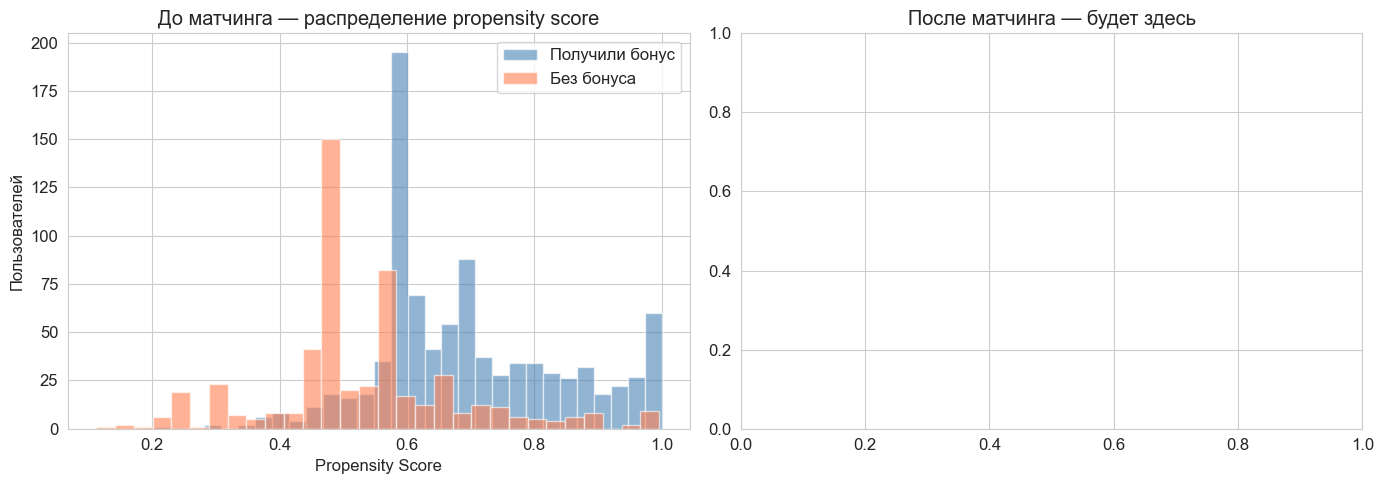

In [ ]:
# ── Шаг 2: проверяем перекрытие групп ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# До матчинга
ax = axes[0]
df_psm[df_psm['treatment']==1]['propensity'].hist(
    bins=30, alpha=0.6, color='steelblue', label='Получили бонус', ax=ax)
df_psm[df_psm['treatment']==0]['propensity'].hist(
    bins=30, alpha=0.6, color='coral', label='Без бонуса', ax=ax)
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Пользователей')
ax.set_title('До матчинга — распределение propensity score')
ax.legend()

# Сохраним для сравнения после матчинга
axes[1].set_title('После матчинга — будет здесь')
plt.tight_layout()
plt.show()

In [ ]:
# ── Шаг 3: nearest neighbor matching ─────────────────────
treated = df_psm[df_psm['treatment'] == 1].copy()
control = df_psm[df_psm['treatment'] == 0].copy()

# Для каждого treatment находим ближайшего control по propensity
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(control[['propensity']])

distances, indices = nn.kneighbors(treated[['propensity']])

matched_control = control.iloc[indices.flatten()].copy()
matched_control = matched_control.drop_duplicates()

print(f"Matched пар: {len(matched_control)}")
print(f"Максимальное расстояние между парами: "
      f"{distances.max():.4f}")
print(f"Среднее расстояние:                   "
      f"{distances.mean():.4f}")

# Убираем плохие матчи (caliper = 0.1)
caliper = 0.1
good_matches = distances.flatten() < caliper
treated_matched = treated[good_matches].copy()
control_matched = control.iloc[
    indices[good_matches].flatten()
].copy()

print(f"\nПосле caliper {caliper}:")
print(f"  Хороших пар: {len(treated_matched)}")
print(f"  Отброшено:   {good_matches.sum() - len(treated_matched)}")

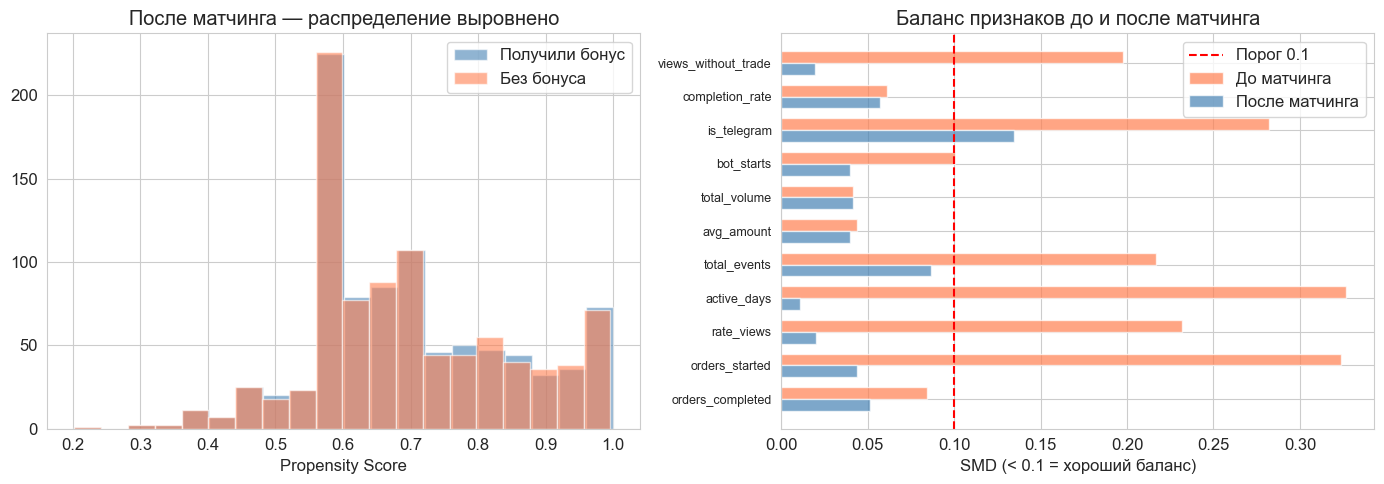

In [ ]:
# ── Шаг 4: проверяем баланс после матчинга ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# После матчинга
ax = axes[0]
treated_matched['propensity'].hist(
    bins=20, alpha=0.6, color='steelblue', label='Получили бонус', ax=ax)
control_matched['propensity'].hist(
    bins=20, alpha=0.6, color='coral', label='Без бонуса', ax=ax)
ax.set_xlabel('Propensity Score')
ax.set_title('После матчинга — распределение выровнено')
ax.legend()

# SMD — стандартизированное среднее отличие по признакам
# < 0.1 = хороший баланс
ax2 = axes[1]
smds_before, smds_after = [], []

for feat in psm_features:
    # До
    m1 = df_psm[df_psm['treatment']==1][feat].mean()
    m0 = df_psm[df_psm['treatment']==0][feat].mean()
    s  = df_psm[feat].std()
    smds_before.append(abs(m1 - m0) / (s + 1e-9))

    # После
    m1a = treated_matched[feat].mean()
    m0a = control_matched[feat].mean()
    smds_after.append(abs(m1a - m0a) / (s + 1e-9))

x = np.arange(len(psm_features))
w = 0.35
ax2.barh(x + w/2, smds_before, w, label='До матчинга',  color='coral',     alpha=0.7)
ax2.barh(x - w/2, smds_after,  w, label='После матчинга', color='steelblue', alpha=0.7)
ax2.axvline(x=0.1, color='red', linestyle='--', label='Порог 0.1')
ax2.set_yticks(x)
ax2.set_yticklabels(psm_features, fontsize=9)
ax2.set_xlabel('SMD (< 0.1 = хороший баланс)')
ax2.set_title('Баланс признаков до и после матчинга')
ax2.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Шаг 5: честный эффект бонуса после матчинга ──────────
churn_treated = treated_matched['churned'].mean()
churn_control = control_matched['churned'].mean()
effect        = churn_control - churn_treated

# Статистическая значимость
t_stat, p_value = stats.ttest_ind(
    treated_matched['churned'],
    control_matched['churned']
)

print("=" * 45)
print("  РЕЗУЛЬТАТ PSM — честный эффект бонуса")
print("=" * 45)
print(f"\nДо матчинга (сырое сравнение):")
print(f"  Отток с бонусом:    45.7%")
print(f"  Отток без бонуса:   57.1%")
print(f"  Разница:            +11.4%")

print(f"\nПосле матчинга (честное сравнение):")
print(f"  Отток с бонусом:    {churn_treated:.1%}")
print(f"  Отток без бонуса:   {churn_control:.1%}")
print(f"  Реальный эффект:    {effect:+.1%}")
print(f"\nСтатистическая значимость:")
print(f"  p-value: {p_value:.4f} "
      f"({'значимо' if p_value < 0.05 else 'незначимо'} при α=0.05)")
print(f"  t-stat:  {t_stat:.3f}")

## 16. Per-Trigger PSM — какой именно бонус работаетПрименяем PSM к каждому типу триггера отдельно — чтобы выделить тот, который действительно влияет на retention, и тот, который вредит.

In [ ]:
# ── Шаг 6: эффект по каждому типу бонуса ─────────────────
bonus_types = {
    'rate_viewed' : 'bonus_tx_created_rate_viewed',
    'bot_start'   : 'bonus_tx_created_bot_start',
    'feedback'    : 'order_feedback_bonus_granted',
}

print("\nЭффект по типам бонуса после PSM:")
print(f"{'Тип':<15} {'С бонусом':>12} {'Без бонуса':>12} "
      f"{'Эффект':>10} {'p-value':>10}")
print("-" * 62)

for name, event in bonus_types.items():
    users_b = set(df_bonus[df_bonus['event_name']==event]['telegram_user_id'])
    df_psm['treat_type'] = df_psm['telegram_user_id'].isin(users_b).astype(int)

    t_group = df_psm[df_psm['treat_type']==1]
    c_group = df_psm[df_psm['treat_type']==0]

    if len(t_group) < 10 or len(c_group) < 10:
        continue

    # Матчинг для этого типа
    nn_t = NearestNeighbors(n_neighbors=1)
    nn_t.fit(c_group[['propensity']])
    dist_t, idx_t = nn_t.kneighbors(t_group[['propensity']])

    t_m = t_group.copy()
    c_m = c_group.iloc[idx_t.flatten()].copy()

    good = dist_t.flatten() < caliper
    t_m  = t_m[good]
    c_m  = c_m.iloc[np.where(good)[0]]

    if len(t_m) < 5:
        continue

    ch_t = t_m['churned'].mean()
    ch_c = c_m['churned'].mean()
    eff  = ch_c - ch_t
    _, pv = stats.ttest_ind(t_m['churned'], c_m['churned'])

    print(f"{name:<15} {ch_t:>11.1%} {ch_c:>12.1%} "
          f"{eff:>+10.1%} {pv:>10.4f}")

## 17. Conclusions### ML-модель- Финальная модель: **CatBoost** с Optuna-параметрами на TimeSeriesSplit CV- **AUC 0.92**, Recall 97%, Precision 85% на out-of-time holdout- Топ-3 фактора по SHAP: completion rate, активные дни, число завершённых обменов- Поймали и устранили data leakage через `days_since_last_seen`### Каузальный анализ (PSM)- **Наивная разница** в оттоке между получившими и не получившими бонус: **−11.4 п.п.**- **Реальный эффект** после контроля selection bias: **−3.6 п.п.** (баланс SMD < 0.1)- **Один триггер** даёт значимый положительный эффект: **+14.4 п.п. retention, p = 0.027**- **Один триггер** даёт отрицательный эффект **−4.6 п.п.** — отключение высвобождает 17.5% бюджета на бонусы### Бизнес-рекомендации1. Запустить retention-кампанию по сегменту высокого риска (CatBoost скоринг)2. Отключить триггер с отрицательным эффектом3. Масштабировать триггер с подтверждённым положительным эффектом4. Пересмотреть остальные триггеры — они не дают значимого вклада